In [103]:
"""spectral analysis(colormaster alpha 1.0)"""
"""By Matija Breljak"""
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from colorist import ColorRGB

Pipeline=[]
LightSource=[]
FilmList=pd.read_csv("Film-List.csv")
ElementList=pd.read_csv("Element_List.csv")
SmpList=pd.read_csv("Sample-List.csv")
method=0 #default is 0 for averaging exposure(other values will be added for median, log and other possible methods)
##defs
def PdtoA(PDin, x):
  return np.array(PDin.iloc[:, x])
def IntegrateChannel(Channel):
  z=0
  x, y = PdtoA(Channel, 0), PdtoA(Channel, 1)
  for i in range(len(x)-1):
    if np.isnan(y[i]) or np.isnan(y[i+1]):
      continue
    else:
      z+=(x[i+1]-x[i])*(y[i]+y[i+1])/2
  return z
def CalculateColorRGB(InSp3, InSp3W):
  chan = lambda df: [IntegrateChannel(df.iloc[:, i:i+2]) for i in (0, 2, 4)]
  R, G, B = chan(InSp3)
  W = max(chan(InSp3W))
  return (int(255*R/W), int(255*G/W), int(255*B/W))
def CalculateExposureLoss(sp1, sp2):
  chan = lambda df: [IntegrateChannel(df.iloc[:, i:i+2]) for i in (0, 2, 4)]
  losses = [np.log2(a / (0.0001 + b)) for a, b in zip(chan(sp1), chan(sp2))]
  return (*losses, np.average(losses))
def ApplyFilter(InSp,Element):
  x_coords, y_coords = InSp.iloc[:, 0], InSp.iloc[:, 1]
  filter_x, filter_y = Element.iloc[:, 0], Element.iloc[:, 1]
  interpolated_filter = np.interp(x_coords, filter_x, filter_y)
  return pd.DataFrame({"x": x_coords.tolist(), "y": (y_coords * interpolated_filter).tolist()})
def ApplyPipeline(InSp,Pipeline):
  InSp = InSp.copy()
  for i in range(len(Pipeline)):
    InSp=ApplyFilter(InSp,Pipeline[i])
  return InSp
def FilterFilm(InSp3, Pipeline):
  print(InSp3.shape)
  chan = lambda df: [ApplyPipeline(df.iloc[:, i:i+2], Pipeline) for i in (0, 2, 4)]
  return pack(*chan(InSp3))
def pack(InSp1, InSp2, InSp3):
  xc, yc, xm, ym, xy, yy = PdtoA(InSp1, 0), PdtoA(InSp1, 1), PdtoA(InSp2, 0), PdtoA(InSp2, 1), PdtoA(InSp3, 0), PdtoA(InSp3, 1)
  return pd.DataFrame({ "xc": xc, "yc": yc, "xm": xm, "ym": ym, "xy": xy, "yy":yy})
def CorrectSpectrumAVG(InSp3):
  InSp3 = InSp3.copy()
  chan = lambda df: [IntegrateChannel(df.iloc[:, i:i+2]) for i in (0, 2, 4)]
  R, G, B = chan(InSp3)
  T = np.average([R, G, B])
  InSp3.iloc[:, [1, 3, 5]] = InSp3.iloc[:, [1, 3, 5]] * (T / np.array([R, G, B]))
  return InSp3
def ApplySampleSP(InSp3, SampleSP):
  chan = lambda df: [ApplyFilter(df.iloc[:, i:i+2], SampleSP) for i in (0, 2, 4)]
  return pack(*chan(InSp3))
def GenerateLightSource(T): #Abs crno telo
  x = np.arange(350, 801, 1)
  y = 1/((x**5)*np.expm1(1.4388e7/(x*T)))
  y = y/np.max(y)
  return pd.DataFrame({"x": x, "y": y})

def InputReportToTextFile(Pipeline):
  with open("InputReport.txt", "w") as f:
    f.write("Pipeline:\n")
    for i, element in enumerate(Pipeline):
      f.write(f"Element {i+1}:\n")
      f.write(element.to_string(index=False))
      f.write("\n\n")


In [118]:
print("choose film")
print(FilmList)
Film=pd.read_csv(str(FilmList.iloc[int(input("Film number: "))-1,1]))
Film.iloc[:, [1, 3, 5]] = 10 ** Film.iloc[:, [1, 3, 5]] #linearization
e=0

while(e!=-2):
  print("choose filters/elements (enter -1 if you finnished with adding filters)")
  print(ElementList.to_string(index=False))
  e=int(input("Filter number: "))-1
  if e == -2:
    break
  Pipeline.append(pd.read_csv(str(ElementList.iloc[e,1])))
print("choose test sample")
print(SmpList)
TestSmp=pd.read_csv(str(SmpList.iloc[int(input("Test sample number: "))-1,1]))
print("only white correction method avaliable is average")
T = input("Set light source temperature in kelvins (default is 2856K): ")
if T == "":
  T = 2856
else:
  T = float(T)
Light = GenerateLightSource(T)




choose film
   x                          y
0  1  Kodak-Portra-800-data.csv
choose filters/elements (enter -1 if you finnished with adding filters)
 x              y
 1 KB-12-data.csv
 2 KR-12-data.csv
 3  CC40-data.csv
choose filters/elements (enter -1 if you finnished with adding filters)
 x              y
 1 KB-12-data.csv
 2 KR-12-data.csv
 3  CC40-data.csv
choose test sample
   x                           y
0  1  LEAF-REFLECTANCE2-data.csv
only white correction method avaliable is average


In [105]:
InputReportToTextFile(Pipeline)


In [117]:
def plot_spectra(spectra, labels, title):
    plt.figure(figsize=(10, 6))
    for spectrum, label in zip(spectra, labels):
        plt.plot(spectrum.iloc[:, 0], spectrum.iloc[:, 1], label=label)
def CorrectGamma255(color, gamma=2.2):
    r = int((color[0] / 255) ** (1 / gamma) * 255)
    g = int((color[1] / 255) ** (1 / gamma) * 255)
    b = int((color[2] / 255) ** (1 / gamma) * 255)
    return (r, g, b)
def ResultingSpectra(Film, Pipeline, TestSmp, Light):
    Lightpipeline = [Light]
    LightCorrectedFilm = FilterFilm(Film, Lightpipeline)
    FilteredFilm = FilterFilm(LightCorrectedFilm, Pipeline)
    CorrectedFilm = CorrectSpectrumAVG(FilteredFilm)
    SampledFilm = ApplySampleSP(CorrectedFilm, TestSmp)
    return [Film, LightCorrectedFilm, FilteredFilm, CorrectedFilm, SampledFilm]
def ResultingColors(Spectra, light):
    colors = []
    for spectrum in Spectra:
        color = CalculateColorRGB(spectrum, light)
        colors.append(CorrectGamma255(color))
    return colors
def ResultingExposureLoss(Spectra):
    losses = []
    for i in range(len(Spectra) - 1):
        loss = CalculateExposureLoss(Spectra[i], Spectra[i + 1])
        losses.append(loss)
    return losses

plotting spectra...


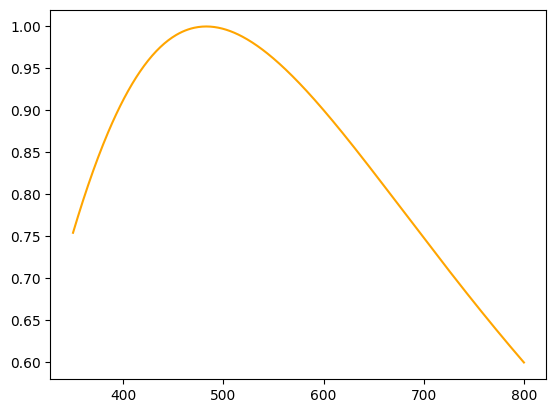

(44, 6)
(44, 6)


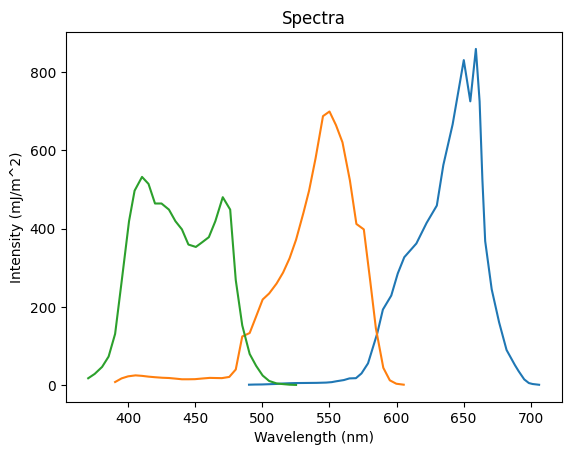

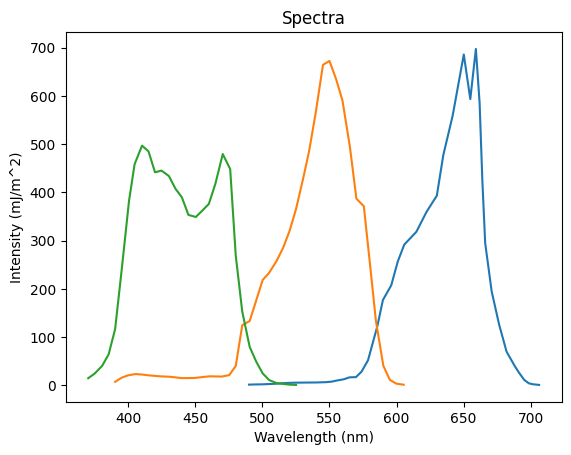

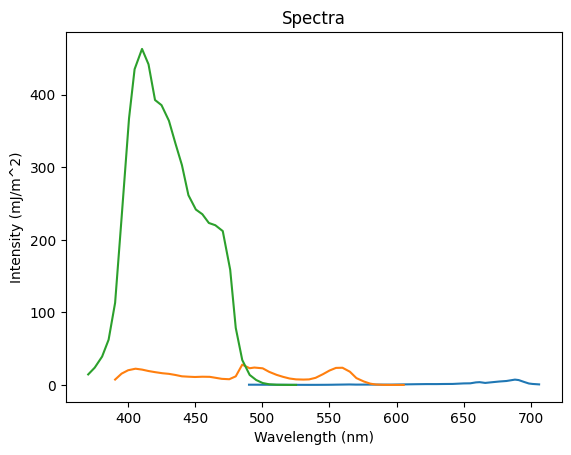

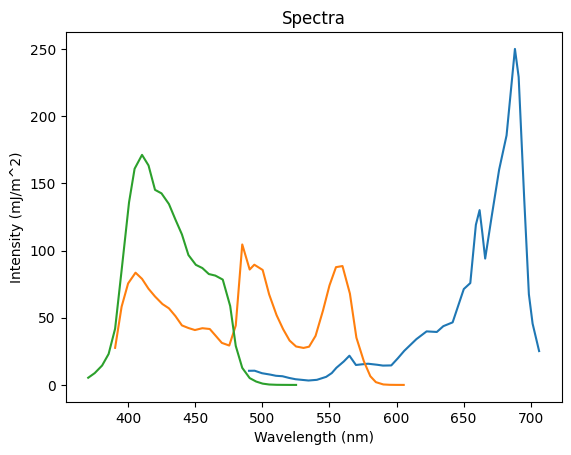

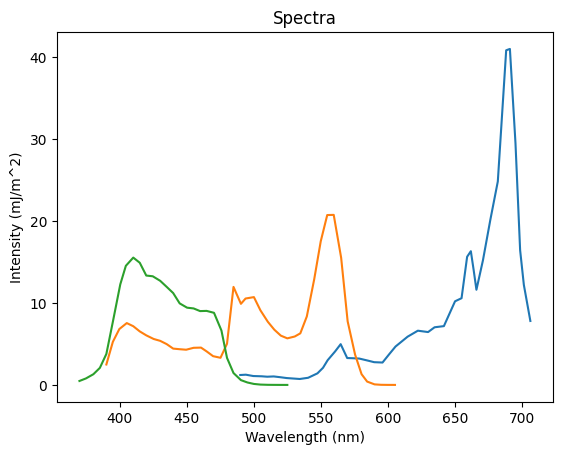

In [119]:
print("plotting spectra...")
plt.plot(Light.iloc[:, 0], Light.iloc[:, 1], label='Light Source', color='orange')
plt.show()
spectra = ResultingSpectra(Film, Pipeline, TestSmp, Light)
for i in range(len(spectra)):
    for j in range(0,3):
        plt.plot(spectra[i].iloc[:, j*2], spectra[i].iloc[:, j*2+1], label=f'Spectrum {i+1}')
    plt.title("Spectra")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (mJ/m^2)")
    plt.show()



In [120]:
#color calculation
from PIL import Image
from IPython.display import display

print("calculating colors...")
print("1-uncorrected film spectrum, 2-light-corrected film spectrum, 3-filtered film spectrum, 4-white-corrected film spectrum, 5-sampled film spectrum")
colors = ResultingColors(spectra, spectra[0])  # Use the light-corrected film spectrum for color calculation
for i, color in enumerate(colors):
    print(f"Color {i+1}: RGB{color}")
    img = Image.new("RGB", (25, 25), color=color)
    display(img)

calculating colors...
1-uncorrected film spectrum, 2-light-corrected film spectrum, 3-filtered film spectrum, 4-white-corrected film spectrum, 5-sampled film spectrum
Color 1: RGB(255, 250, 245)


Color 2: RGB(235, 246, 241)


Color 3: RGB(20, 72, 208)


Color 4: RGB(132, 132, 132)


Color 5: RGB(55, 52, 42)
